# Figures
This notebook analyse the parameters of tompos and generates the following figures:
- diff rate line plot and heatmap
- relative diff rate line plot and heatmap
- Compare pseudodynamics line plot and umap

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys, re, torch, time, PINN
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm.auto import tqdm
# PINN
from PINN import reader, models, pl, tl
# plot
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [2]:
#
ckpt_path = "logs/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=95-total_loss=1.33532071.ckpt"

n_dimension = 10
ct_key = 'anno_man'
use_device="cuda:3"


date = time.strftime("%b%d")
result_dir = "results/" + "/".join(ckpt_path.split("/")[1:3]) + f"_{date}_onbase"
# result_base = re.match(r".*/(version_\d{1,2})/.*", ckpt_path).group(1)
result_base = ckpt_path.split("/")[4]

if not os.path.exists(result_dir):
    try:
        os.mkdir(result_dir)
    except:
        os.mkdir(os.path.dirname(result_dir))
        os.mkdir(result_dir)

plot_save = f'{result_dir}/{result_base}_plot'
if not os.path.exists(plot_save):
    os.mkdir(plot_save)
    

# load model
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")

# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path, map_location=use_device)
device = pde_model.device

data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
full_full_timepoints = adata.uns['pop']['t']


cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]
timepoint_idx = eval(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])
timepoint_idx = timepoint_idx if type(timepoint_idx)==list else  np.arange(timepoint_idx)


# the DS
DS_full = reader.TwoTimpepoint_AnnDS(AnnData=adata, timepoint_idx=None,  
                            n_dimension = n_dimension,
                              cellstate_key=cellstate_key,  #'DM_EigenVector'
                              log_transform=False,
                              norm_time=False,
                              batchsize = 300
                              )


/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.3.0, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


Computing density :
`density_funs` not specified, use gaussian kde


In [3]:
adata

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [4]:
# g v D
g,v,D = pde_model.predict_param(DS_full)
nabla_v = pde_model.predict_nabla_v(DS_full)#.sum(axis=-1);

# v norm
cellstate = torch.from_numpy(DS_full.cellstate).float()
DM_range = (cellstate.max(axis=0).values - cellstate.min(axis=0).values).cpu().numpy()
v_norm = v / DM_range[None,None,:]
v_norm2 = np.sqrt(np.power(v_norm,2).mean(axis=2))

v_sum = np.sqrt(np.power(v,2).mean(axis=2))

In [5]:
adata.obsm['g'] = g.T
adata.obsm['v_sum'] = v_sum.T
adata.obsm['v_norm'] = v_norm2.T
adata.obsm['nabla_v'] = nabla_v.T
adata.obsm['D'] = D.T

In [82]:
np.save('results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/g.npy', g.T)
np.save('results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/v_sum.npy', v_sum.T)
np.save('results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/v_norm.npy', v_norm2.T)
np.save('results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/nabla_v.npy', nabla_v.T)
np.save('results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/D.npy', D.T)

$| \vec{v} |$

In [7]:
plt.ioff()  # Turn interactive plotting off to prevent figure display

fig, axs = pl.params_in_umap(adata, v_sum, param=r'$| \vec{v} |$', cell_of_t=True, subplot_kws={"dpi":600})

for i,t in enumerate(adata.uns['pop']['t']):
    axs[i].set_title("Day"+str(t)+" "+r'$| \vec{v} |$')

fig.savefig("figures/tompos_vsum.pdf",format='pdf')

plt.close(fig) 

prediction of shape (9, 49390)


In [8]:
plt.ioff()  # Turn interactive plotting off to prevent figure display

pl.params_in_umap(adata, v_sum, param=r'$| \vec{v}_{norm} |$', cell_of_t=True, subplot_kws={"dpi":600})

for i, t in enumerate(adata.uns['pop']['t']):
    axs[i].set_title("Day" + str(t) + " " + r'$| \vec{v}_{norm} |$')

fig.savefig("figures/tompos_v_norm_sum.pdf", format='pdf')
plt.close(fig)  # Close the figure to prevent display

prediction of shape (9, 49390)


# compute the relative differentiation speed

<font size=2 color='gray'>
Next we calculate the average differentiation rate for each cell type and each timepoint. The variable v denotes the velocity of each cell in 10-dimensional cell state space. The cell type label can be found at obs anno_man and timepoint label at timepoint_tx_days. So the following task: 1. look for the most appropriate way to transform the high-dimensional velocity vector to a scaler for each cell. The scaler can best represent the differentiation rate of cell transiting in the high dimensional space. You can look for more than 1 transformtion. 2. calculate the average rate for cell type at each timepoint, which means you will return me a celltype x timepoint variable. 3. Look for appropritate visualization to plot the dynamic differentiation rate, showing the time-wise and celltype-wise differentaition rate pattern. The color of each cell type should be consistant with the umap. Color can be found in adata.uns['anno_man_colors'].
</font>

## Transforming High-Dimensional Velocity to a Scalar

### Euclidean norm (L2 norm):  


<font size=2.5>
$$ \text{rate}_i = |\vec{v}i|2 = \sqrt{\sum{d=1}^{n} v{i,d}^2} $$

This is the most interpretable as the "speed" in state space.  
</font>
### L1 norm:

<font size=2.5>
$$ \text{rate}_i = |\vec{v}i|1 = \sum{d=1}^{n} |v{i,d}| $$
Sometimes used for robustness to outliers.
Projection onto principal direction:
Project velocity onto the first principal component of cell state space (optional, more advanced).
Let’s use both L2 and L1 norms for comparison.

</font>

In [9]:
# 1. Calculate scalar rates for each cell
v_l2 = np.linalg.norm(v, axis=2).T  # shape: (n_cells, n_timepoints)
v_l1 = np.sum(np.abs(v), axis=2).T  # shape: (n_cells, n_timepoints)

# 2. Prepare DataFrame for aggregation
df = pd.DataFrame({
    'celltype': adata.obs['anno_man'].values,
    'timepoint': adata.obs['timepoint_tx_days'].values
})

# For each timepoint, add the corresponding velocity norm
for t_idx, t in enumerate(adata.uns['pop']['t']):
    df[f'v_l2_{t}'] = v_l2[:, t_idx]
    df[f'v_l1_{t}'] = v_l1[:, t_idx]

# Melt to long format for easier groupby
df_long = df.melt(id_vars=['celltype', 'timepoint'], 
                  value_vars=[col for col in df.columns if col.startswith('v_l2_')],
                  var_name='timepoint_var', value_name='v_l2')
df_long['timepoint'] = df_long['timepoint_var'].str.replace('v_l2_', '').astype(float)

# Group by celltype and timepoint, calculate mean
rate_matrix = df_long.groupby(['celltype', 'timepoint'])['v_l2'].mean().unstack()
# rate_matrix: rows=celltype, columns=timepoint

# Get consistent colors for cell types
celltype_order = list(rate_matrix.index)
celltype_colors = dict(zip(celltype_order, adata.uns['anno_man_colors']))

# Line plot
# Count number of cells per celltype and timepoint
cell_counts = (
    adata.obs.groupby(['anno_man', 'timepoint_tx_days'])
    .size()
    .unstack(fill_value=0)
)



In [10]:
rate_matrix

timepoint,3.0,7.0,12.0,27.0,49.0,76.0,112.0,161.0,269.0
celltype,,,,,,,,,
Bas/MC prog,0.079927,0.082987,0.088094,0.106896,0.127735,0.135648,0.128301,0.108843,0.082604
Eos,0.082409,0.081058,0.080913,0.090063,0.110581,0.121040,0.114655,0.095628,0.073252
Ery,0.092600,0.093334,0.095838,0.109696,0.128972,0.138171,0.132273,0.112722,0.084358
HSC,0.080589,0.082869,0.087037,0.103698,0.123365,0.131582,0.125215,0.106138,0.079007
Int prog,0.079229,0.080852,0.084311,0.100144,0.120714,0.129719,0.123355,0.104125,0.077910
Ly,0.076221,0.080063,0.085890,0.105047,0.124661,0.132045,0.125143,0.106354,0.080415
Meg,0.101380,0.100556,0.100450,0.106748,0.122883,0.132969,0.129015,0.109857,0.077929
Mono/DC prog,0.069941,0.072151,0.076489,0.094904,0.117396,0.126741,0.120059,0.101215,0.077144
Neu,0.096092,0.093461,0.091128,0.092103,0.107135,0.118872,0.114914,0.096281,0.071542


Recommended:

Heatmap: celltype (rows) × timepoint (columns), colored by average rate.
Line plot: x=timepoint, y=rate, one line per celltype, colored by adata.uns['anno_man_colors'].

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


In [45]:
dpi = 60
plt.ioff()

# --- Line plot: only show cell types with >10 cells at any timepoint ---
fig = plt.figure(figsize=(10, 6), dpi=dpi)
for ct in rate_matrix.index:
    # Mask: only plot if celltype has >10 cells at any timepoint
    n_cells = cell_counts.loc[ct] if ct in cell_counts.index else pd.Series(0, index=rate_matrix.columns)
    if (n_cells > 10).any():
        y = rate_matrix.loc[ct]
        x = rate_matrix.columns
        plt.plot(x, y, label=ct, color=celltype_colors[ct])
        # Add dots only at timepoints where n_cells > 10
        plt.scatter(x[n_cells > 10], y[n_cells > 10], color=celltype_colors[ct], s=40, zorder=3)
plt.xlabel('Timepoint (days)')
plt.ylabel('Relative Differentiation Rate (vs HSC)')
plt.title('Relative Differentiation Rate Dynamics by Cell Type (vs HSC)')
# plt.axhline(1, color='gray', linestyle='--', linewidth=1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

if dpi==600:
    fig.savefig("figures/tompos_cellxtime_v_line.pdf",format='pdf')
    plt.close(fig) 


In [46]:
# Heatmap

dpi = 60

# --- Heatmap: blank grid if <10 cells ---
# Mask values with <10 cells
masked_matrix = rate_matrix.copy()
for ct in masked_matrix.index:
    for t in masked_matrix.columns:
        if cell_counts.loc[ct, t] < 10:
            masked_matrix.loc[ct, t] = np.nan
# Remove 'HSC' and 'Eos' rows from the heatmap
rows_to_remove = []

if 'Eos' in masked_matrix.index:
    rows_to_remove.append('Eos')
masked_matrix_plot = masked_matrix.drop(rows_to_remove, errors='ignore')

# Ensure timepoints are integers for the x-axis
masked_matrix_plot.columns = masked_matrix_plot.columns.astype(int)

plt.ioff()
fig2 = plt.figure(figsize=(10, len(masked_matrix_plot.index)*0.5 + 2), dpi=dpi)

sns.heatmap(
    masked_matrix_plot, 
    cmap='viridis',
    annot=True, 
    fmt=".2f",
    cbar_kws={'label': 'Relative Differentiation Rate (vs HSC)'}, 
    mask=masked_matrix_plot.isna(), 
    linewidths=0.5, 
    linecolor='white'
)
plt.xlabel('Timepoint (days)')
plt.ylabel('Cell Type')
plt.title('Relative Differentiation Rate Heatmap (vs HSC)')
plt.tight_layout()

if dpi==600:
    fig2.savefig("figures/tompos_cellxtime_v_heatmap.pdf",format='pdf')
    plt.close(fig) 


### Calculate the relative rate over HSC

In [ ]:
# Replace 'HSC' with the exact string used for HSC in your adata.obs['anno_man']
hsc_label = 'HSC'  # Change if your label is different
if hsc_label not in rate_matrix.index:
    raise ValueError(f"HSC label '{hsc_label}' not found in celltype index.")

relative_rate_matrix = rate_matrix.divide(rate_matrix.loc[hsc_label], axis=1)

In [47]:
dpi = 60
plt.ioff()

# Count number of cells per celltype and timepoint
cell_counts = (
    adata.obs.groupby(['anno_man', 'timepoint_tx_days'])
    .size()
    .unstack(fill_value=0)
)

# --- Line plot: only show cell types with >10 cells at any timepoint ---
fig3 = plt.figure(figsize=(10, 6), dpi=dpi)
for ct in relative_rate_matrix.index:
    # Mask: only plot if celltype has >10 cells at any timepoint
    n_cells = cell_counts.loc[ct] if ct in cell_counts.index else pd.Series(0, index=relative_rate_matrix.columns)
    if (n_cells > 10).any():
        y = relative_rate_matrix.loc[ct]
        x = relative_rate_matrix.columns
        plt.plot(x, y, label=ct, color=celltype_colors[ct])
        # Add dots only at timepoints where n_cells > 10
        plt.scatter(x[n_cells > 10], y[n_cells > 10], color=celltype_colors[ct], s=40, zorder=3)
plt.xlabel('Timepoint (days)')
plt.ylabel('Relative Differentiation Rate (vs HSC)')
plt.title('Relative Differentiation Rate Dynamics by Cell Type (vs HSC)')
plt.axhline(1, color='gray', linestyle='--', linewidth=1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

if dpi==600:
    fig3.savefig("figures/tompos_cellxtime_relative_v_line.pdf",format='pdf')
    plt.close(fig) 

In [48]:
# --- Heatmap: blank grid if <10 cells ---
# Mask values with <10 cells
masked_matrix = relative_rate_matrix.copy()
for ct in masked_matrix.index:
    for t in masked_matrix.columns:
        if cell_counts.loc[ct, t] < 10:
            masked_matrix.loc[ct, t] = np.nan
# Remove 'HSC' and 'Eos' rows from the heatmap
rows_to_remove = []
if 'HSC' in masked_matrix.index:
    rows_to_remove.append('HSC')
if 'Eos' in masked_matrix.index:
    rows_to_remove.append('Eos')
masked_matrix_plot = masked_matrix.drop(rows_to_remove, errors='ignore')

# Ensure timepoints are integers for the x-axis
masked_matrix_plot.columns = masked_matrix_plot.columns.astype(int)


dpi=60
plt.ioff()
fig4 = plt.figure(figsize=(10, len(masked_matrix_plot.index)*0.5 + 2), dpi=dpi)

sns.heatmap(
    masked_matrix_plot, 
    cmap='coolwarm', 
    center=1, 
    annot=True, 
    fmt=".2f",
    cbar_kws={'label': 'Relative Differentiation Rate (vs HSC)'}, 
    mask=masked_matrix_plot.isna(), 
    linewidths=0.5, 
    linecolor='white'
)
plt.xlabel('Timepoint (days)')
plt.ylabel('Cell Type')
plt.title('Relative Differentiation Rate Heatmap (vs HSC)')
plt.tight_layout()

if dpi==600:
    fig4.savefig("figures/tompos_cellxtime_relative_v_heatmap.pdf",format='pdf')
    plt.close(fig) 

In [50]:
fig, fig2, fig3, fig4

(<Figure size 600x360 with 1 Axes>,
 <Figure size 600x360 with 2 Axes>,
 <Figure size 600x360 with 1 Axes>,
 <Figure size 600x330 with 2 Axes>)

# read clu7 and clu11 pseudodynamics params

In [36]:
from importlib import reload
reload(tl)

<module 'PINN.functions' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/functions/__init__.py'>

In [13]:
adata

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [ ]:
g_project = tl.aggregate_params_by_pseudotime(params, adata, param_names='g v2', timepoints=None,  pseudotime_key='pseudotime_scaled',nbins=100, return_y=True)

In [16]:
clu7_params = pd.read_csv("data/HSCP_PD_params/clu7/table_all_parameters_clu_7.csv", index_col=0)
clu10_params = pd.read_csv("data/HSCP_PD_params/clu10/table_all_parameters_clu_10.csv", index_col=0)
clu11_params = pd.read_csv("data/HSCP_PD_params/clu11/table_all_parameters_clu_11.csv", index_col=0)

In [43]:
clu7_params.dpt_pseudotime_scaled.max()

0.99665993

In [17]:
overlap_idx = clu7_params.index.intersection(adata.obs_names)
clu7_params = clu7_params.loc[overlap_idx]
# Subset adata by index in clu7_params
adata_clu7 = adata[clu7_params.index].copy()
adata_clu7

AnnData object with n_obs × n_vars = 8681 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'lo

In [50]:
# Project parameters: g, v_sum, v_norm
param_arrays = {
    'growth rate': 'g',
    'diff rate': 'v_sum',
    'norm diff rate': 'v_norm'
}
param_names = list(param_arrays.keys())

# Helper to plot parameter vs pseudotime for a cluster
def plot_param_vs_pseudotime(adata_full, clu_params, param_arrays, cluster_name):
    """
    """
    pseudotime = clu_params['dpt_pseudotime_scaled'].values
    order = np.argsort(pseudotime)
    pseudotime_sorted = pseudotime[order]

    overlap_idx = clu_params.index.intersection(adata_full.obs_names)
    clu_params = clu_params.loc[overlap_idx]
    # Subset adata by index in clu_params
    adata_clu = adata_full[clu_params.index].copy()
    adata_clu.obs['dpt_pseudotime_scaled'] = clu_params['dpt_pseudotime_scaled'].values
    # Assign drift and growth to adata.obs

    x_smooth = np.linspace(0, adata_clu.obs['dpt_pseudotime_scaled'].max(), 100)
    x_smooth = (x_smooth[1:] + x_smooth[:-1])/2  # Remove last point to match length
    print("X smooth shape", x_smooth.shape)
    

    fig, axs = plt.subplots(len(param_arrays), 1, figsize=(8, 3*len(param_arrays)), dpi=100)

    i = 0
    for pname, param_key in param_arrays.items():
    
        pint_project = tl.aggregate_params_by_pseudotime(adata_clu, adata_clu.obsm[param_key].T, 
                                        param_names=pname, timepoints=None, pseudotime_key='dpt_pseudotime',
                                        nbins=100, return_y=True)

        # if len(param_arrays) == 1:
        #     axs = [axs]
        
        # Projected param along pseudotime
        for it, day in enumerate(adata_full.uns['pop']['t']):
            axs[i].plot(x_smooth, pint_project[it], label=f'PINT Day{day} {pname}', color='tab:blue')
        axs[i].legend()
        # Param from param_clu_df
        if pname == 'growth rate':
            y_clu = clu_params['growth'].values[order]
        elif pname == 'diff rate':
            y_clu = clu_params['drift'].values[order]
        elif pname == 'norm diff rate':
            y_clu = clu_params['drift'].values[order]
        else:
            continue

        ax2 = axs[i].twinx()  
        ax2.plot(pseudotime_sorted, y_clu, label='Pseudodynamics', color='tab:orange', alpha=0.7)
        axs[i].set_ylabel(pname)
        axs[i].legend()
        axs[i].set_title(f"{cluster_name} {pname}")
        axs[-1].set_xlabel('dpt_pseudotime')

        i += 1
    fig.suptitle(f"{cluster_name}: PINN vs Pseudodynamics parameters")
    plt.tight_layout()
    plt.show()

X smooth shape (99,)


/tmp/ipykernel_69983/3155415703.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


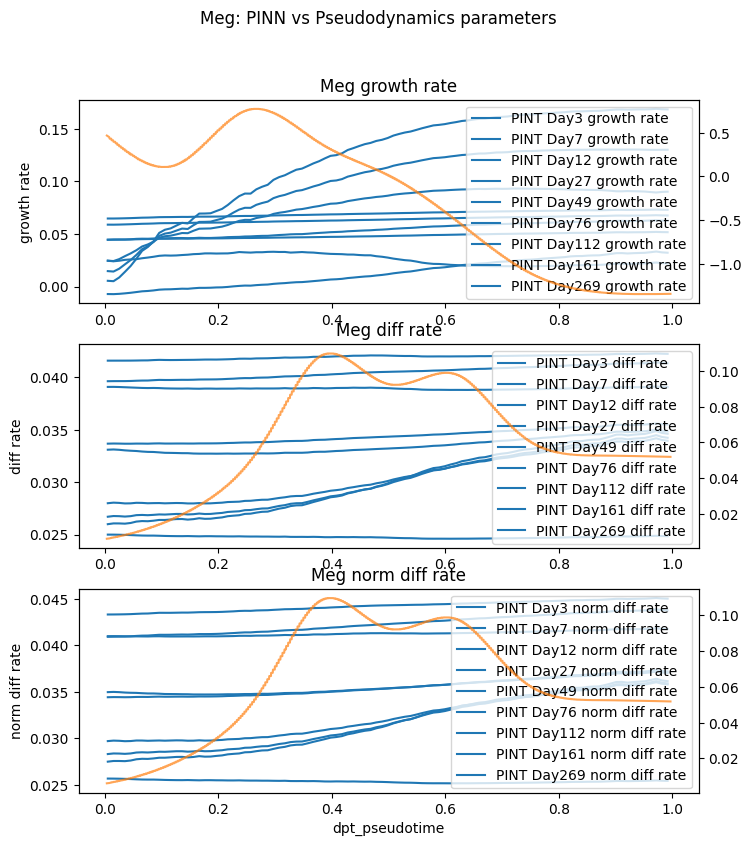

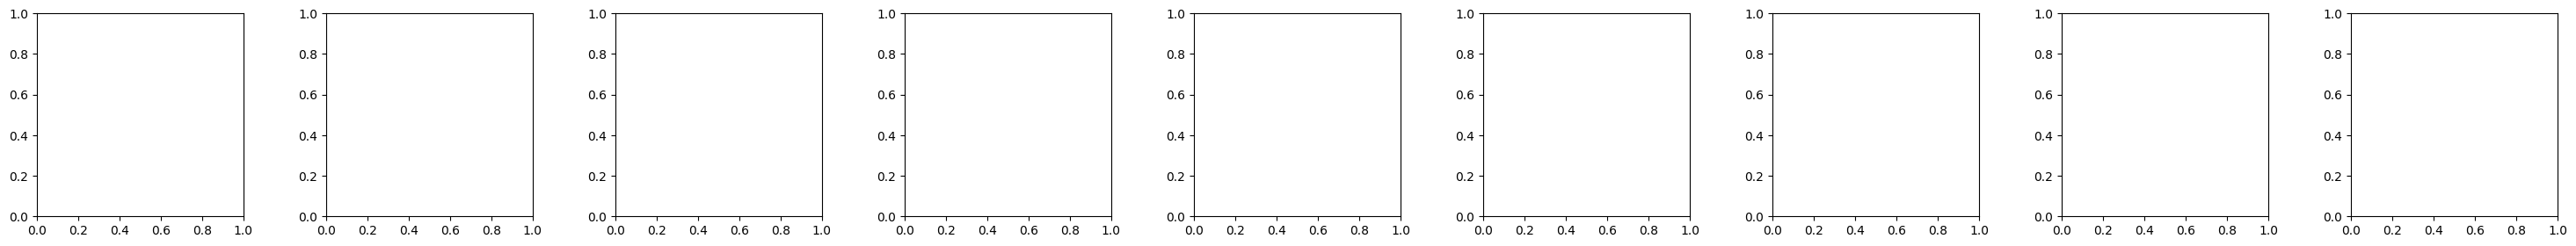

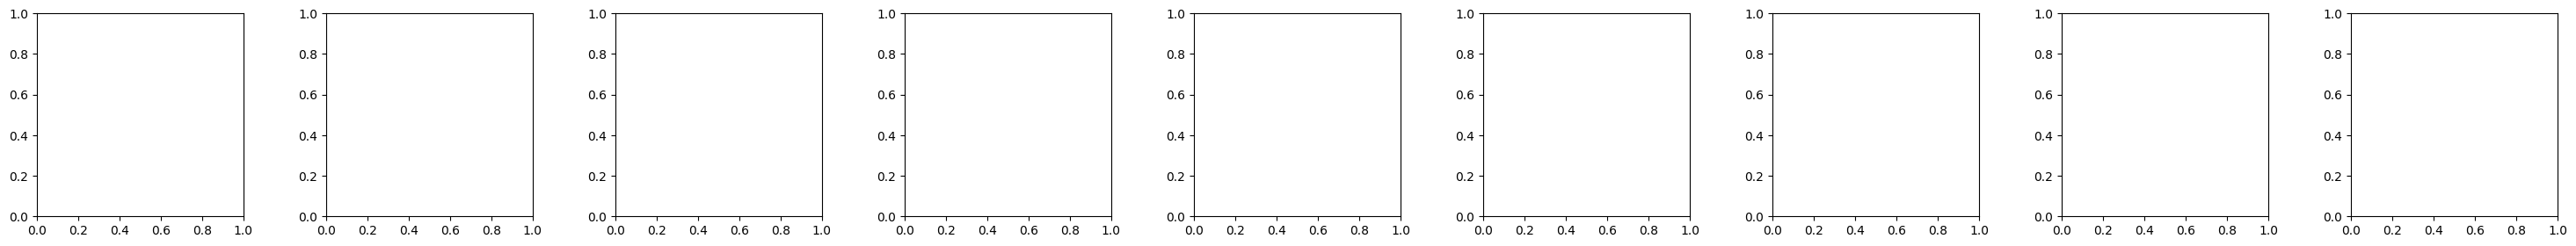

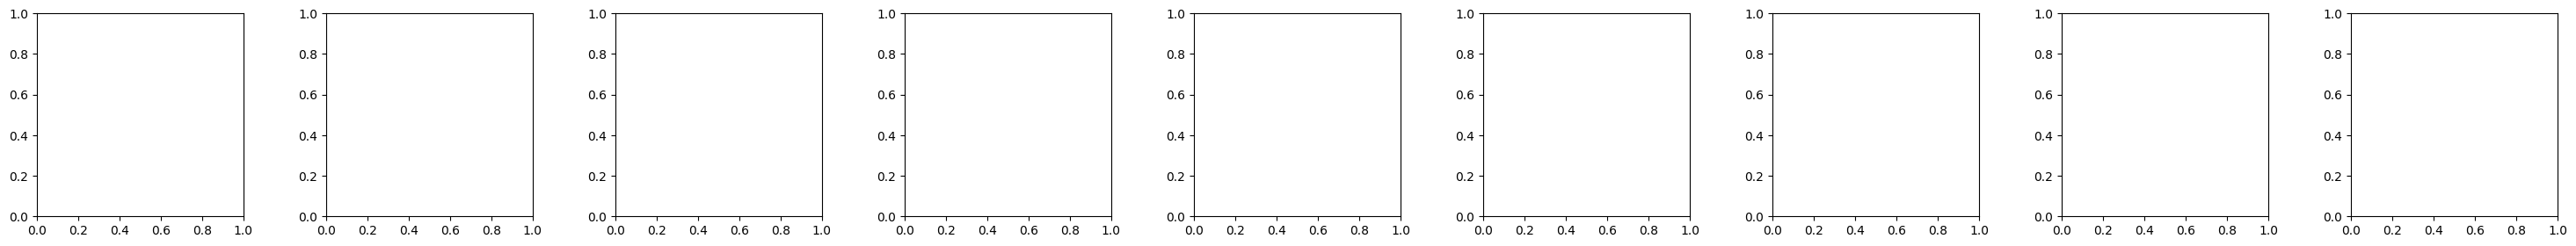

In [51]:
# # Iterate through clu7, clu10, clu11
# for clu_params,  clu_name in [
#     (clu7_params,  "Meg"),
#     (clu10_params,  "Ery"),
#     (clu11_params,  "Neu"),
# ]:
#     # Prepare projected arrays for this cluster
    
plot_param_vs_pseudotime(adata, clu7_params, param_arrays, "Meg")

In [79]:
param_names = {
    "g":"growth",
    "v_norm": "drift", 
    "v_sum": "drift",
}

# Helper function to compare drift with L2 norm differentiation rate on UMAP
def compare_drift_vs_rate(adata_full, clu_params, timepoints, cluster_name, pname, save_path=None):
    """
    Compare drift (from clu_params) with L2 norm differentiation rate (from obsm['v_sum']) on UMAP.
    Parameters: 
        adata_full: Full AnnData object containing UMAP coordinates.
        clu_params: DataFrame with cluster parameters including 'drift'.
        timepoints: List of timepoints corresponding to the columns in obsm['v_sum'].
        cluster_name: Name of the cluster for labeling the plots.
        pname : Dictionary mapping obsm keys to parameter names for plotting.
        save_path: Optional path to save the figure.
    Returns:    
        adata_clu: Subset AnnData object for the cluster with drift and rate_l2 added to obs.
    """
    pdy_pname = param_names[pname]
    pint_pname = pname 

    # Subset adata by index in clu_params
    overlap_idx = clu_params.index.intersection(adata_full.obs_names)
    clu_params = clu_params.loc[overlap_idx]
    # Subset adata by index in clu_params
    adata_clu = adata_full[clu_params.index].copy()
    # Assign drift and growth to adata.obs
    
    adata_clu.obs[pdy_pname] = clu_params[pdy_pname].values


    # Assign L2 norm rate (from obsm['v_sum']) to adata.obs
    # Each column in v_sum corresponds to a timepoint in 'timepoints'
    v_sum = adata_clu.obsm[pint_pname]

    if save_path is not None:
        plt.ioff()
        dpi = 600
    else:
        dpi = 50
    # Plot UMAP colored by drift and by rate_l2
    fig, axs = plt.subplots(1, 1+len(timepoints), figsize=(30, 3), dpi=dpi)
    sc.pl.umap(adata, ax=axs[0], s=40, show=False, alpha= 0.5)
    sc.pl.umap(adata_clu, color=pdy_pname, ax=axs[0], s=40, show=False, frameon=False,title=f"{cluster_name} pseudodynamics {pdy_pname}")

    for it in range(len(timepoints)):
        day =  timepoints[it]
        adata_clu.obs['rate'] = v_sum[:,it].copy()
        sc.pl.umap(adata, ax=axs[1+it], s=40, show=False, alpha= 0.5)
        sc.pl.umap(adata_clu[adata_clu.obs['timepoint_tx_days'] ==day], color='rate', ax=axs[1+it], s=40, show=False, frameon=False, title=f"{cluster_name} Day{day} PINT {pdy_pname}")
    plt.tight_layout()
    
    if save_path is not None:
        fig.savefig(save_path, format='pdf')
        plt.close()
    return adata_clu

In [80]:
# Example for clu7, clu10, clu11
plot_save = 'figures/tompos_param_compare'
adata_clu7 = compare_drift_vs_rate(adata, clu7_params, adata.uns['pop']['t'], "Meg", 'v_norm', save_path=f"{plot_save}/Meg_drift_vnorm.pdf")
adata_clu10 = compare_drift_vs_rate(adata, clu10_params, adata.uns['pop']['t'], "Neu", 'v_norm', save_path=f"{plot_save}/Neu_drift_vnorm.pdf")
adata_clu11 = compare_drift_vs_rate(adata, clu11_params, adata.uns['pop']['t'], "Ery", 'v_norm', save_path=f"{plot_save}/Ery_drift_vnorm.pdf")


In [81]:
# Example for clu7, clu10, clu11
adata_clu7 = compare_drift_vs_rate(adata, clu7_params, adata.uns['pop']['t'], "Meg", 'g', save_path=f"{plot_save}/Meg_growth.pdf")
adata_clu10 = compare_drift_vs_rate(adata, clu10_params, adata.uns['pop']['t'], "Neu", 'g', save_path=f"{plot_save}/Neu_growth.pdf")
adata_clu11 = compare_drift_vs_rate(adata, clu11_params, adata.uns['pop']['t'], "Ery", 'g', save_path=f"{plot_save}/Ery_growth.pdf")
